# 🚦 Urban Traffic Zone Analyser — Bangalore
## K-Means + DBSCAN Clustering
**Dataset:** [Bangalore's Traffic Pulse — Kaggle](https://www.kaggle.com/datasets/preethamgouda/banglore-city-traffic-dataset)

**Objective:** Cluster Bengaluru urban zones by traffic behavior using K-Means (zone segmentation) and DBSCAN (anomaly/hotspot detection).

## Cell 1 — Install & Imports

In [ ]:
# Uncomment if running fresh on Colab
# !pip install scikit-learn pandas numpy matplotlib seaborn plotly imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.pipeline import Pipeline
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings('ignore')

print("All imports successful ✅")

All imports successful ✅


## Cell 2 — Load Dataset

In [ ]:
# Upload the CSV manually in Colab:
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('Banglore_traffic_Dataset.csv')  # change path if needed

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nNull values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Shape: (8936, 16)

Columns:
 ['Date', 'Area Name', 'Road/Intersection Name', 'Traffic Volume', 'Average Speed', 'Travel Time Index', 'Congestion Level', 'Road Capacity Utilization', 'Incident Reports', 'Environmental Impact', 'Public Transport Usage', 'Traffic Signal Compliance', 'Parking Usage', 'Pedestrian and Cyclist Count', 'Weather Conditions', 'Roadwork and Construction Activity']

Null values:
 Date                                  0
Area Name                             0
Road/Intersection Name                0
Traffic Volume                        0
Average Speed                         0
Travel Time Index                     0
Congestion Level                      0
Road Capacity Utilization             0
Incident Reports                      0
Environmental Impact                  0
Public Transport Usage                0
Traffic Signal Compliance             0
Parking Usage                         0
Pedestrian and Cyclist Count          0
Weather Conditions                 

## Cell 3 — EDA: Basic Stats

In [ ]:
print(df.describe())
print("\nArea Names:", df['Area Name'].unique())
print("Weather Conditions:", df['Weather Conditions'].unique())

       Traffic Volume  Average Speed  Travel Time Index  Congestion Level  \
count     8936.000000    8936.000000        8936.000000       8936.000000   
mean     29236.048120      39.447427           1.375554         80.818041   
std      13001.808801      10.707244           0.165319         23.533182   
min       4233.000000      20.000000           1.000039          5.160279   
25%      19413.000000      31.775825           1.242459         64.292905   
50%      27600.000000      39.199368           1.500000         92.389018   
75%      38058.500000      46.644517           1.500000        100.000000   
max      72039.000000      89.790843           1.500000        100.000000   

       Road Capacity Utilization  Incident Reports  Environmental Impact  \
count                8936.000000       8936.000000           8936.000000   
mean                   92.029215          1.570389            108.472096   
std                    16.583341          1.420047             26.003618   
mi

## Cell 4 — EDA: Feature Distributions

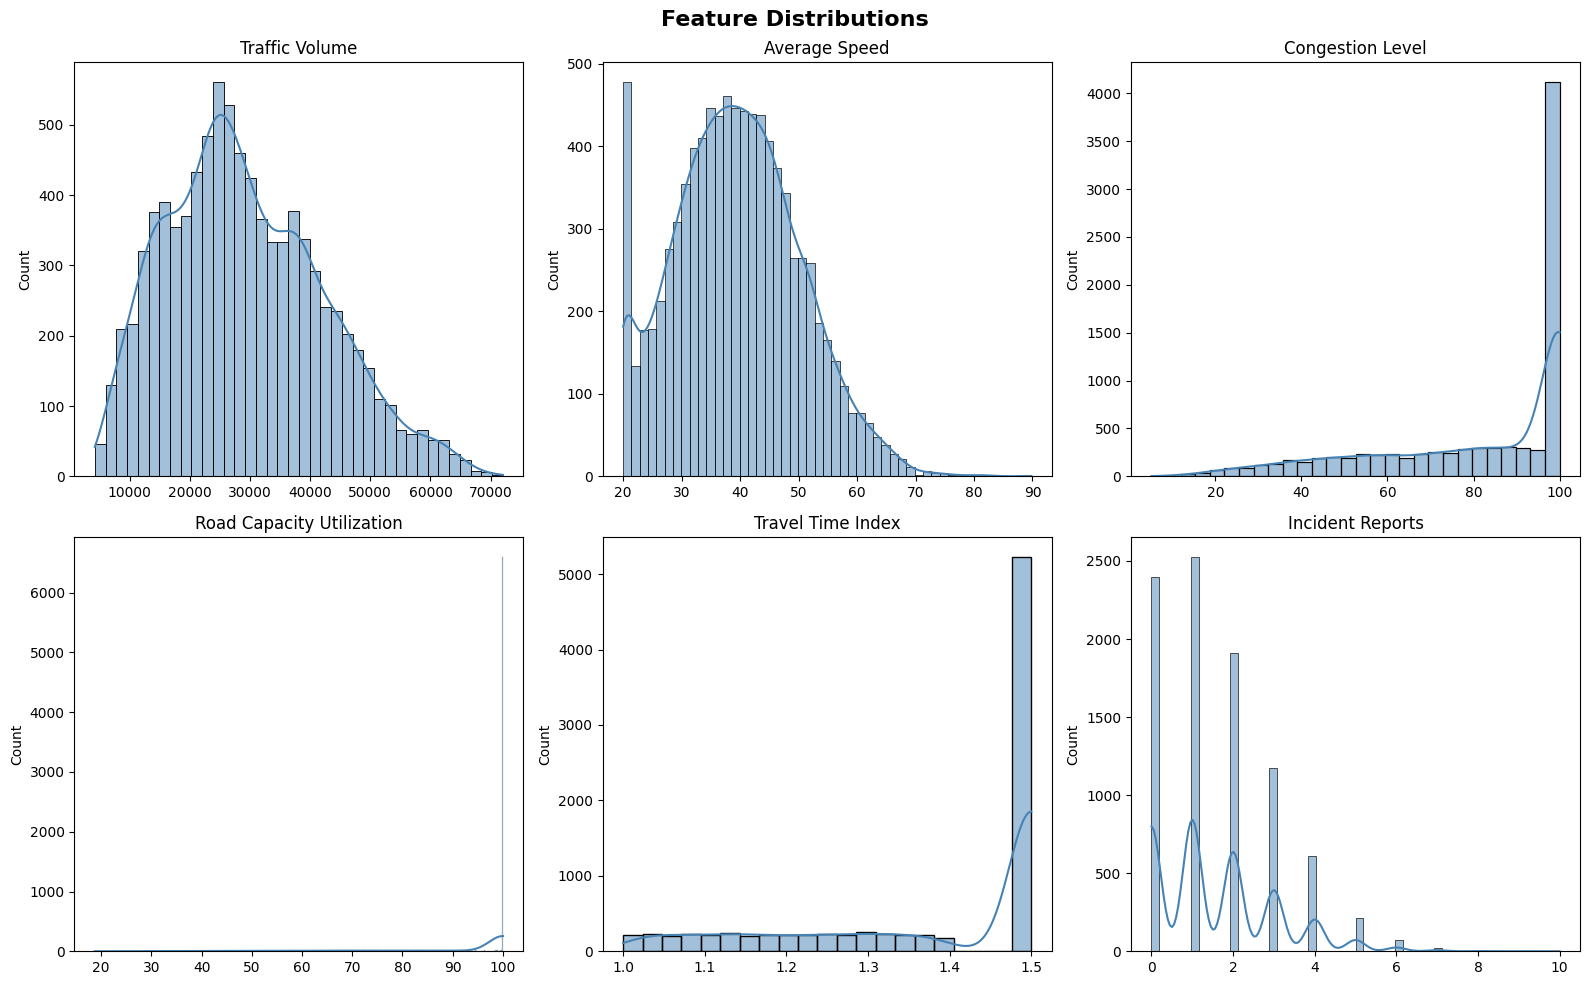

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold')

num_cols = ['Traffic Volume', 'Average Speed', 'Congestion Level',
            'Road Capacity Utilization', 'Travel Time Index', 'Incident Reports']

for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], ax=ax, kde=True, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 5 — EDA: Congestion by Area

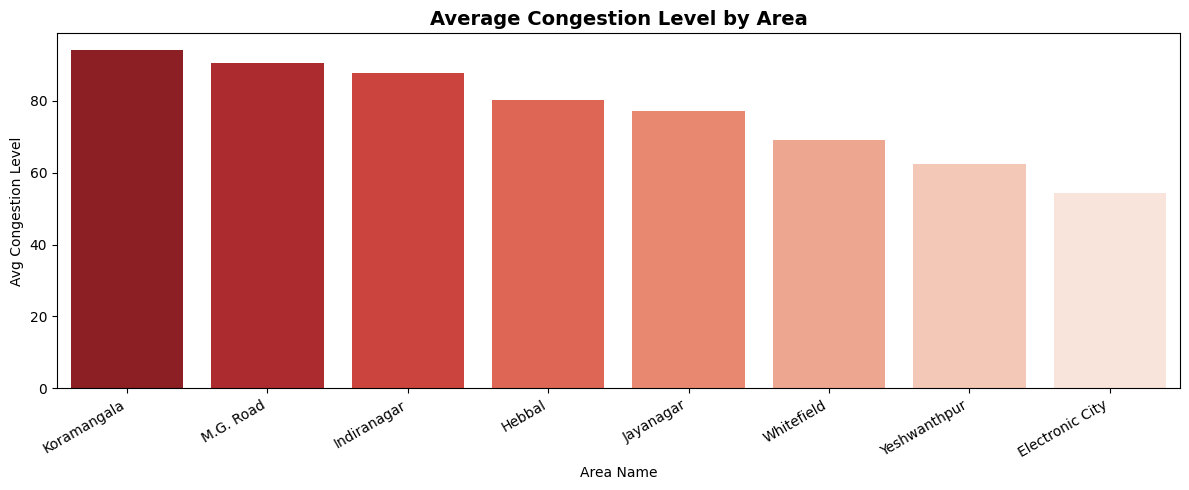

In [ ]:
plt.figure(figsize=(12, 5))
area_congestion = df.groupby('Area Name')['Congestion Level'].mean().sort_values(ascending=False)
sns.barplot(x=area_congestion.index, y=area_congestion.values, palette='Reds_r')
plt.title('Average Congestion Level by Area', fontsize=14, fontweight='bold')
plt.ylabel('Avg Congestion Level')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('congestion_by_area.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 6 — EDA: Correlation Heatmap

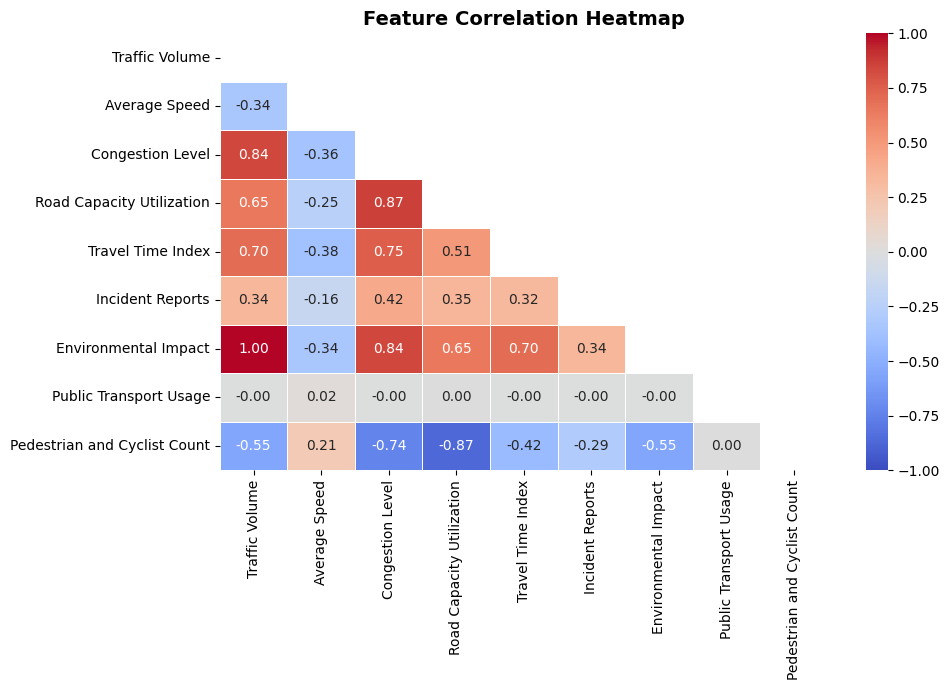

In [ ]:
plt.figure(figsize=(10, 7))
corr_cols = ['Traffic Volume', 'Average Speed', 'Congestion Level',
             'Road Capacity Utilization', 'Travel Time Index',
             'Incident Reports', 'Environmental Impact',
             'Public Transport Usage', 'Pedestrian and Cyclist Count']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 7 — EDA: Weather vs Congestion

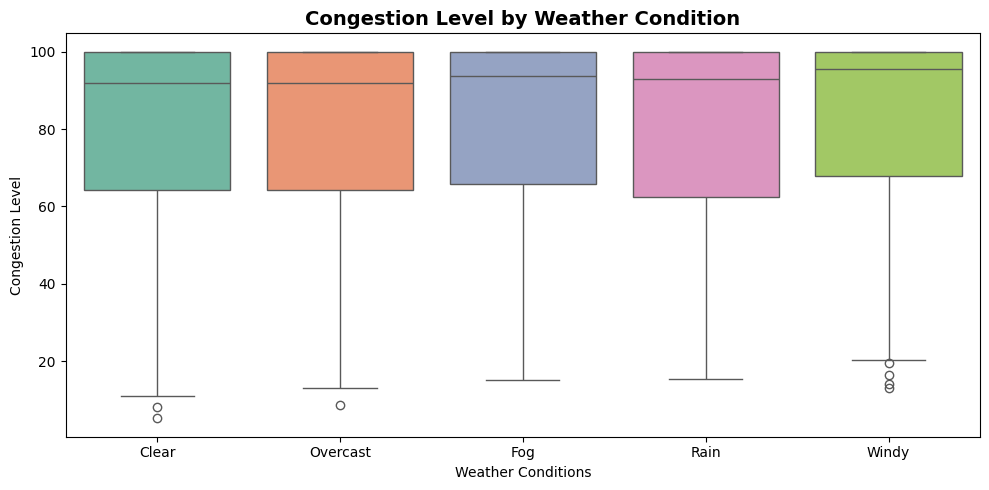

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Weather Conditions', y='Congestion Level', palette='Set2')
plt.title('Congestion Level by Weather Condition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('weather_congestion.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 8 — Feature Engineering

In [ ]:
df_model = df.copy()

# Encode binary categorical
df_model['Roadwork_enc'] = (df_model['Roadwork and Construction Activity'] == 'Yes').astype(int)

# Encode Weather
le = LabelEncoder()
df_model['Weather_enc'] = le.fit_transform(df_model['Weather Conditions'])

# Features for clustering
FEATURES = [
    'Traffic Volume',
    'Average Speed',
    'Congestion Level',
    'Road Capacity Utilization',
    'Travel Time Index',
    'Incident Reports',
    'Environmental Impact',
    'Public Transport Usage',
    'Traffic Signal Compliance',
    'Parking Usage',
    'Pedestrian and Cyclist Count',
    'Roadwork_enc',
    'Weather_enc'
]

X = df_model[FEATURES].copy()
print("Feature matrix shape:", X.shape)
print(X.head())

Feature matrix shape: (8936, 13)
   Traffic Volume  Average Speed  Congestion Level  Road Capacity Utilization  \
0           50590      50.230299        100.000000                 100.000000   
1           30825      29.377125        100.000000                 100.000000   
2            7399      54.474398         28.347994                  36.396525   
3           60874      43.817610        100.000000                 100.000000   
4           57292      41.116763        100.000000                 100.000000   

   Travel Time Index  Incident Reports  Environmental Impact  \
0           1.500000                 0               151.180   
1           1.500000                 1               111.650   
2           1.039069                 0                64.798   
3           1.500000                 1               171.748   
4           1.500000                 3               164.584   

   Public Transport Usage  Traffic Signal Compliance  Parking Usage  \
0               70.63233

## Cell 9 — Standard Scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled shape:", X_scaled.shape)
print("Mean (should be ~0):", X_scaled.mean(axis=0).round(3))
print("Std  (should be ~1):", X_scaled.std(axis=0).round(3))

Scaled shape: (8936, 13)
Mean (should be ~0): [-0. -0. -0. -0.  0. -0. -0. -0.  0.  0.  0.  0. -0.]
Std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Cell 10 — PCA for Visualization

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Explained variance (PC1+PC2): {pca.explained_variance_ratio_.sum()*100:.1f}%")

pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_scaled)

Explained variance (PC1+PC2): 45.8%


## Cell 11 — K-Means: Elbow + Silhouette (Optimal K)

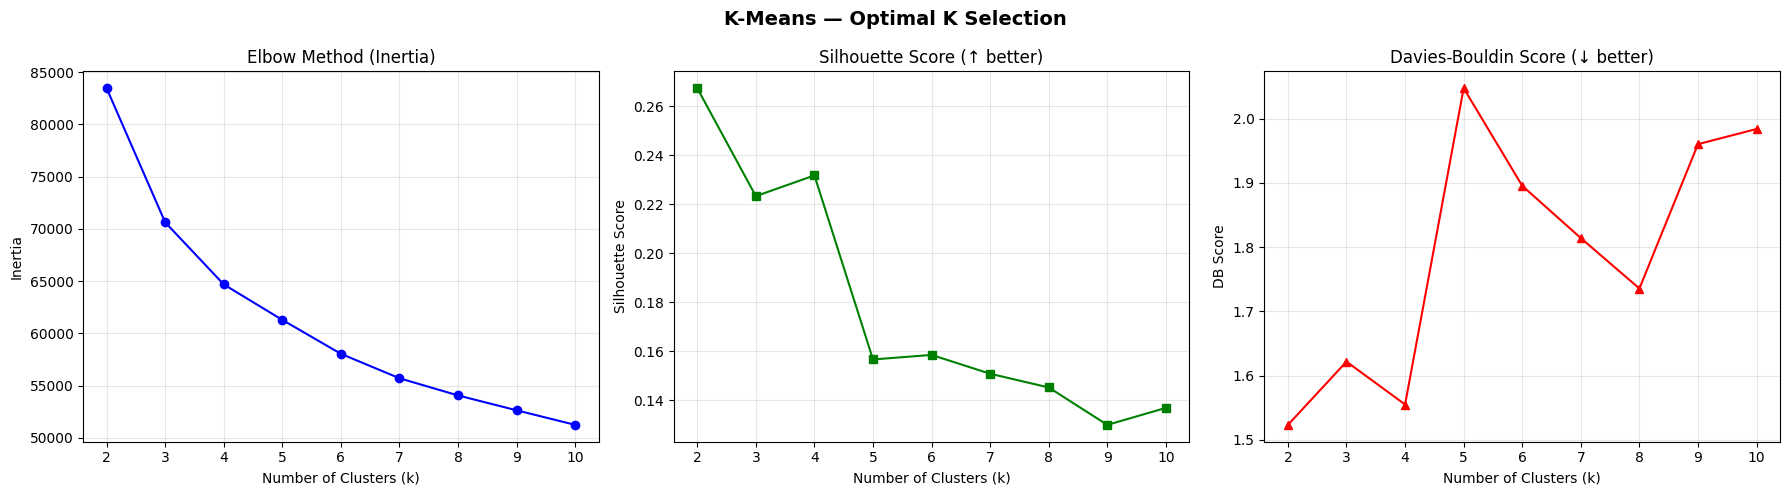


Best k by Silhouette: 2
Silhouette scores: {2: np.float64(0.2673), 3: np.float64(0.2233), 4: np.float64(0.2318), 5: np.float64(0.1567), 6: np.float64(0.1586), 7: np.float64(0.1509), 8: np.float64(0.1453), 9: np.float64(0.13), 10: np.float64(0.137)}


In [ ]:
inertias, silhouettes, db_scores, ch_scores = [], [], [], []
K_RANGE = range(2, 11)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('K-Means — Optimal K Selection', fontsize=14, fontweight='bold')

axes[0].plot(K_RANGE, inertias, 'bo-')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_RANGE, silhouettes, 'gs-')
axes[1].set_title('Silhouette Score (↑ better)')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

axes[2].plot(K_RANGE, db_scores, 'r^-')
axes[2].set_title('Davies-Bouldin Score (↓ better)')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('DB Score')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_selection.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = K_RANGE[np.argmax(silhouettes)]
print(f"\nBest k by Silhouette: {best_k}")
print(f"Silhouette scores: {dict(zip(K_RANGE, [round(s,4) for s in silhouettes]))}")

## Cell 12 — Final K-Means Model

In [ ]:
OPTIMAL_K = best_k  # Override manually if needed, e.g. OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_model['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

print(f"K-Means with k={OPTIMAL_K}")
print("Cluster distribution:\n", df_model['KMeans_Cluster'].value_counts().sort_index())
print(f"Silhouette Score : {silhouette_score(X_scaled, df_model['KMeans_Cluster']):.4f}")
print(f"Davies-Bouldin   : {davies_bouldin_score(X_scaled, df_model['KMeans_Cluster']):.4f}")
print(f"Calinski-Harabasz: {calinski_harabasz_score(X_scaled, df_model['KMeans_Cluster']):.2f}")

K-Means with k=2
Cluster distribution:
 KMeans_Cluster
0    5654
1    3282
Name: count, dtype: int64
Silhouette Score : 0.2673
Davies-Bouldin   : 1.5232
Calinski-Harabasz: 3501.53


## Cell 13 — K-Means: Cluster Profiles & Zone Labels

In [ ]:
profile_cols = ['Traffic Volume', 'Average Speed', 'Congestion Level',
                'Road Capacity Utilization', 'Travel Time Index', 'Incident Reports']

cluster_profile = df_model.groupby('KMeans_Cluster')[profile_cols].mean().round(2)
print("Cluster Profiles:")
print(cluster_profile)

def label_zone(row):
    if row['Congestion Level'] >= 90:
        return 'Critical Zone'
    elif row['Congestion Level'] >= 70:
        return 'High Traffic Zone'
    elif row['Congestion Level'] >= 40:
        return 'Moderate Zone'
    else:
        return 'Free Flow Zone'

cluster_profile['Zone Label'] = cluster_profile.apply(label_zone, axis=1)
print("\nZone Labels:\n", cluster_profile['Zone Label'])

zone_map = cluster_profile['Zone Label'].to_dict()
df_model['Zone Label'] = df_model['KMeans_Cluster'].map(zone_map)

Cluster Profiles:
                Traffic Volume  Average Speed  Congestion Level  \
KMeans_Cluster                                                    
0                     36703.41          35.94             96.20   
1                     16371.80          45.49             54.31   

                Road Capacity Utilization  Travel Time Index  Incident Reports  
KMeans_Cluster                                                                  
0                                   99.99               1.48              2.05  
1                                   78.31               1.19              0.75  

Zone Labels:
 KMeans_Cluster
0    Critical Zone
1    Moderate Zone
Name: Zone Label, dtype: object


## Cell 14 — K-Means: 2D PCA Scatter

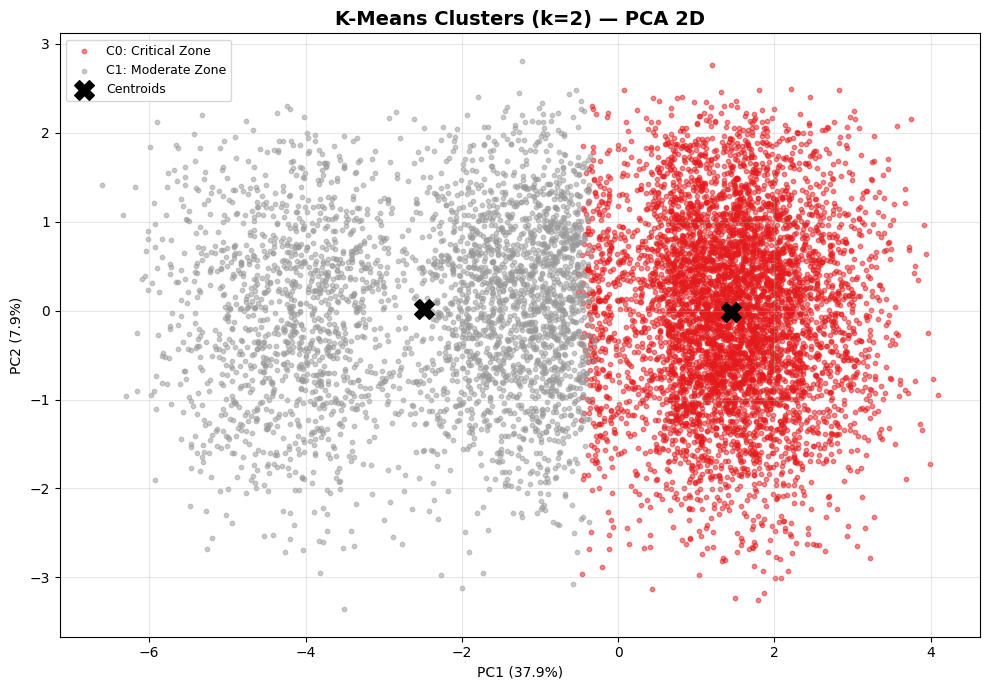

In [ ]:
plt.figure(figsize=(10, 7))
colors = plt.cm.Set1(np.linspace(0, 1, OPTIMAL_K))
for i in range(OPTIMAL_K):
    mask = df_model['KMeans_Cluster'] == i
    label = zone_map.get(i, f'Cluster {i}')
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, alpha=0.5,
                color=colors[i], label=f'C{i}: {label}')

centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=200, marker='X',
            color='black', zorder=5, label='Centroids')

plt.title(f'K-Means Clusters (k={OPTIMAL_K}) — PCA 2D', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kmeans_pca2d.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 15 — K-Means: Cluster Heatmap

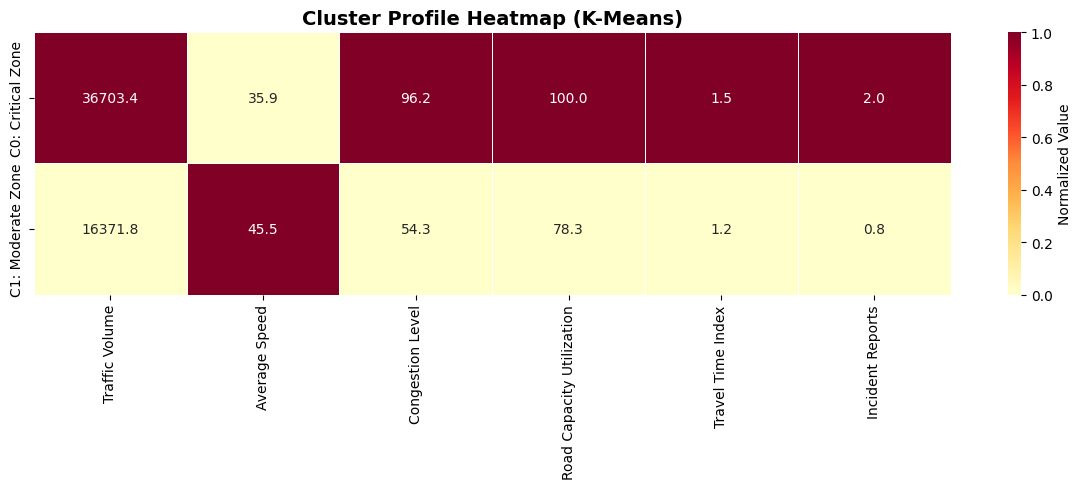

In [ ]:
plt.figure(figsize=(12, 5))
heatmap_data = cluster_profile[profile_cols]
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())
heatmap_norm.index = [f"C{i}: {zone_map[i]}" for i in heatmap_norm.index]
sns.heatmap(heatmap_norm, annot=heatmap_data.values, fmt='.1f',
            cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Normalized Value'})
plt.title('Cluster Profile Heatmap (K-Means)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 16 — K-Means: Area × Zone Distribution

<Figure size 1200x600 with 0 Axes>

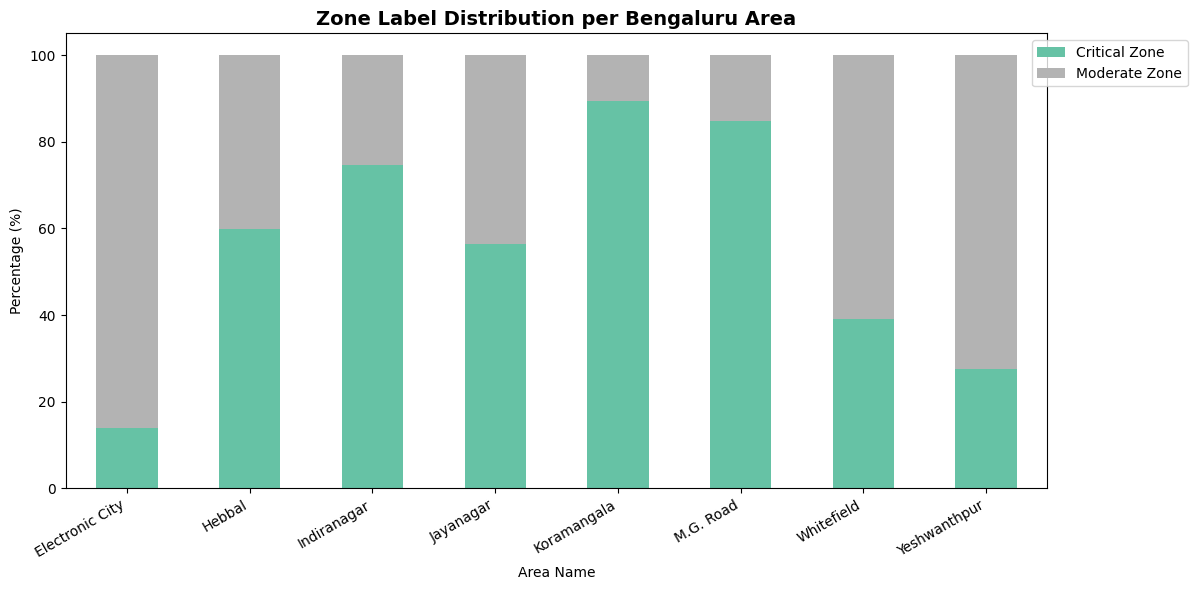

In [ ]:
area_cluster = pd.crosstab(df_model['Area Name'], df_model['Zone Label'], normalize='index') * 100
plt.figure(figsize=(12, 6))
area_cluster.plot(kind='bar', stacked=True, colormap='Set2', figsize=(12, 6))
plt.title('Zone Label Distribution per Bengaluru Area', fontsize=14, fontweight='bold')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.savefig('area_cluster_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 17 — DBSCAN: k-Distance Graph (eps selection)

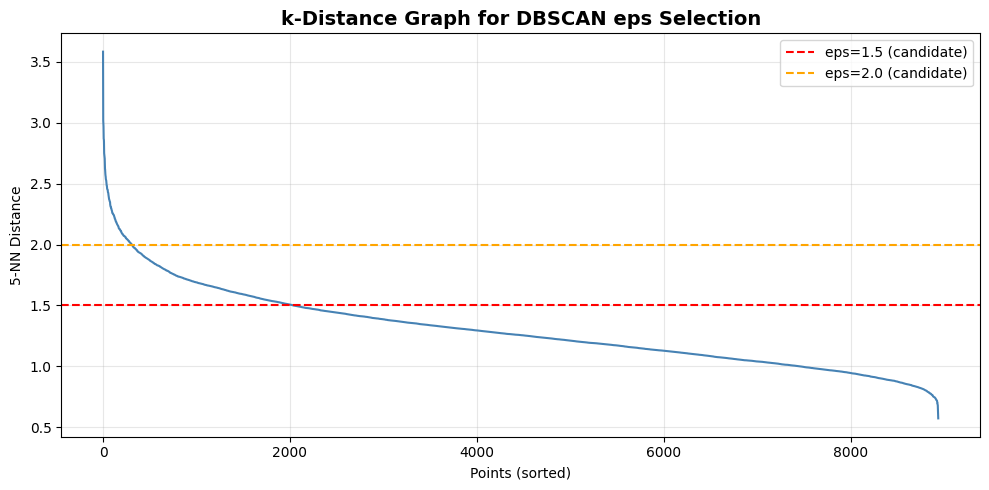

In [ ]:
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances, color='steelblue')
plt.axhline(y=1.5, color='red', linestyle='--', label='eps=1.5 (candidate)')
plt.axhline(y=2.0, color='orange', linestyle='--', label='eps=2.0 (candidate)')
plt.title('k-Distance Graph for DBSCAN eps Selection', fontsize=14, fontweight='bold')
plt.xlabel('Points (sorted)')
plt.ylabel('5-NN Distance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dbscan_kdistance.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 18 — DBSCAN: Grid Search

In [ ]:
eps_values = [0.8, 1.0, 1.2, 1.5, 1.8, 2.0]
min_samples_values = [5, 10, 15, 20]

results = []
for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        noise_pct = n_noise / len(labels) * 100
        sil = silhouette_score(X_scaled, labels) if n_clusters >= 2 else -1
        results.append({
            'eps': eps, 'min_samples': ms,
            'n_clusters': n_clusters, 'n_noise': n_noise,
            'noise_pct': round(noise_pct, 2), 'silhouette': round(sil, 4)
        })

results_df = pd.DataFrame(results)
print("DBSCAN Grid Search Results (top 10 by silhouette):")
print(results_df[results_df['n_clusters'] >= 2].sort_values('silhouette', ascending=False).head(10))

DBSCAN Grid Search Results (top 10 by silhouette):
    eps  min_samples  n_clusters  n_noise  noise_pct  silhouette
16  1.8            5           5      253       2.83      0.1956
19  1.8           20           3      946      10.59      0.1665
17  1.8           10           6      461       5.16      0.1451
23  2.0           20           2      391       4.38      0.1386
21  2.0           10           3      183       2.05      0.1175
22  2.0           15           3      251       2.81      0.1087
18  1.8           15           7      688       7.70      0.1043
20  2.0            5           4       91       1.02      0.0975
15  1.5           20           3     3062      34.27      0.0888
13  1.5           10           6     1815      20.31      0.0454


## Cell 19 — Final DBSCAN Model

In [ ]:
# ✏️ Update these based on grid search results above
BEST_EPS = 1.8
BEST_MIN_SAMPLES = 5

dbscan = DBSCAN(eps=BEST_EPS, min_samples=BEST_MIN_SAMPLES)
db_labels = dbscan.fit_predict(X_scaled)

df_model['DBSCAN_Label'] = db_labels
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = (db_labels == -1).sum()

print(f"DBSCAN (eps={BEST_EPS}, min_samples={BEST_MIN_SAMPLES})")
print(f"Clusters found  : {n_clusters_db}")
print(f"Noise points    : {n_noise_db} ({n_noise_db/len(db_labels)*100:.1f}%)")

if n_clusters_db >= 2:
    non_noise = db_labels != -1
    print(f"Silhouette Score: {silhouette_score(X_scaled[non_noise], db_labels[non_noise]):.4f}")

print("\nLabel distribution:\n", pd.Series(db_labels).value_counts().sort_index())

DBSCAN (eps=1.8, min_samples=5)
Clusters found  : 5
Noise points    : 253 (2.8%)
Silhouette Score: 0.2099

Label distribution:
 -1     253
 0    6834
 1    1129
 2     636
 3      76
 4       8
Name: count, dtype: int64


## Cell 20 — DBSCAN: 2D PCA Scatter

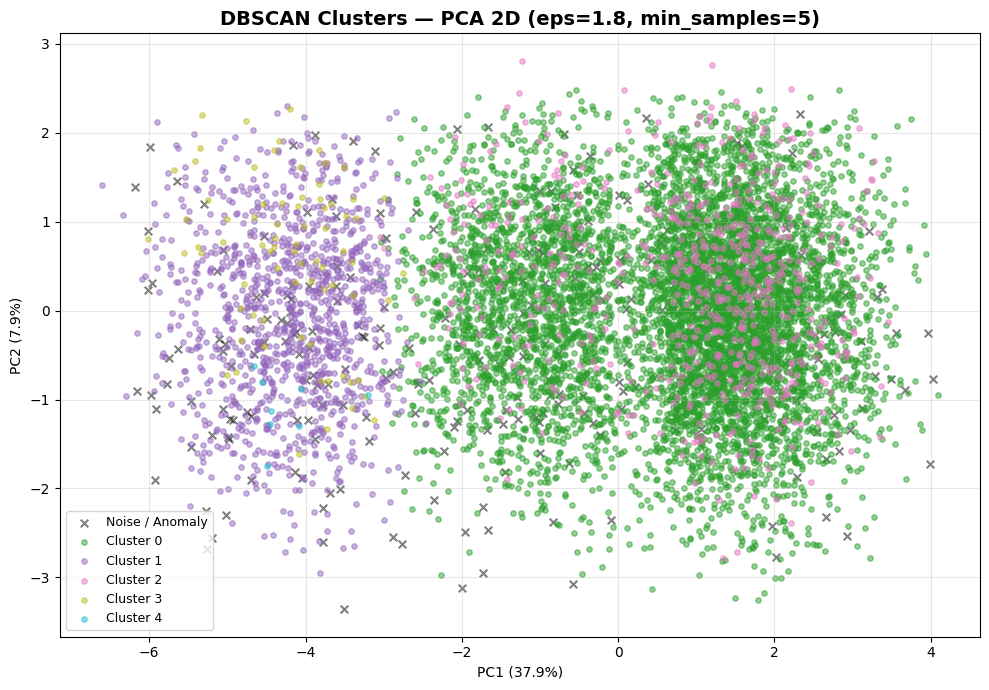

In [ ]:
plt.figure(figsize=(10, 7))
unique_labels = sorted(set(db_labels))
palette = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 2)))

for idx, label in enumerate(unique_labels):
    mask = db_labels == label
    color = 'black' if label == -1 else palette[idx % len(palette)]
    marker = 'x' if label == -1 else 'o'
    name = 'Noise / Anomaly' if label == -1 else f'Cluster {label}'
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=15 if label != -1 else 30,
                alpha=0.5, color=color, marker=marker, label=name)

plt.title(f'DBSCAN Clusters — PCA 2D (eps={BEST_EPS}, min_samples={BEST_MIN_SAMPLES})',
          fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dbscan_pca2d.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 21 — DBSCAN: Anomaly Profile

Anomaly vs Normal — Mean Feature Comparison:
         Traffic Volume  Average Speed  Congestion Level  \
Normal         29448.14          39.28             81.35   
Anomaly        21957.09          45.13             62.56   

         Road Capacity Utilization  Travel Time Index  Incident Reports  
Normal                       92.40               1.38              1.56  
Anomaly                      79.16               1.26              2.07  


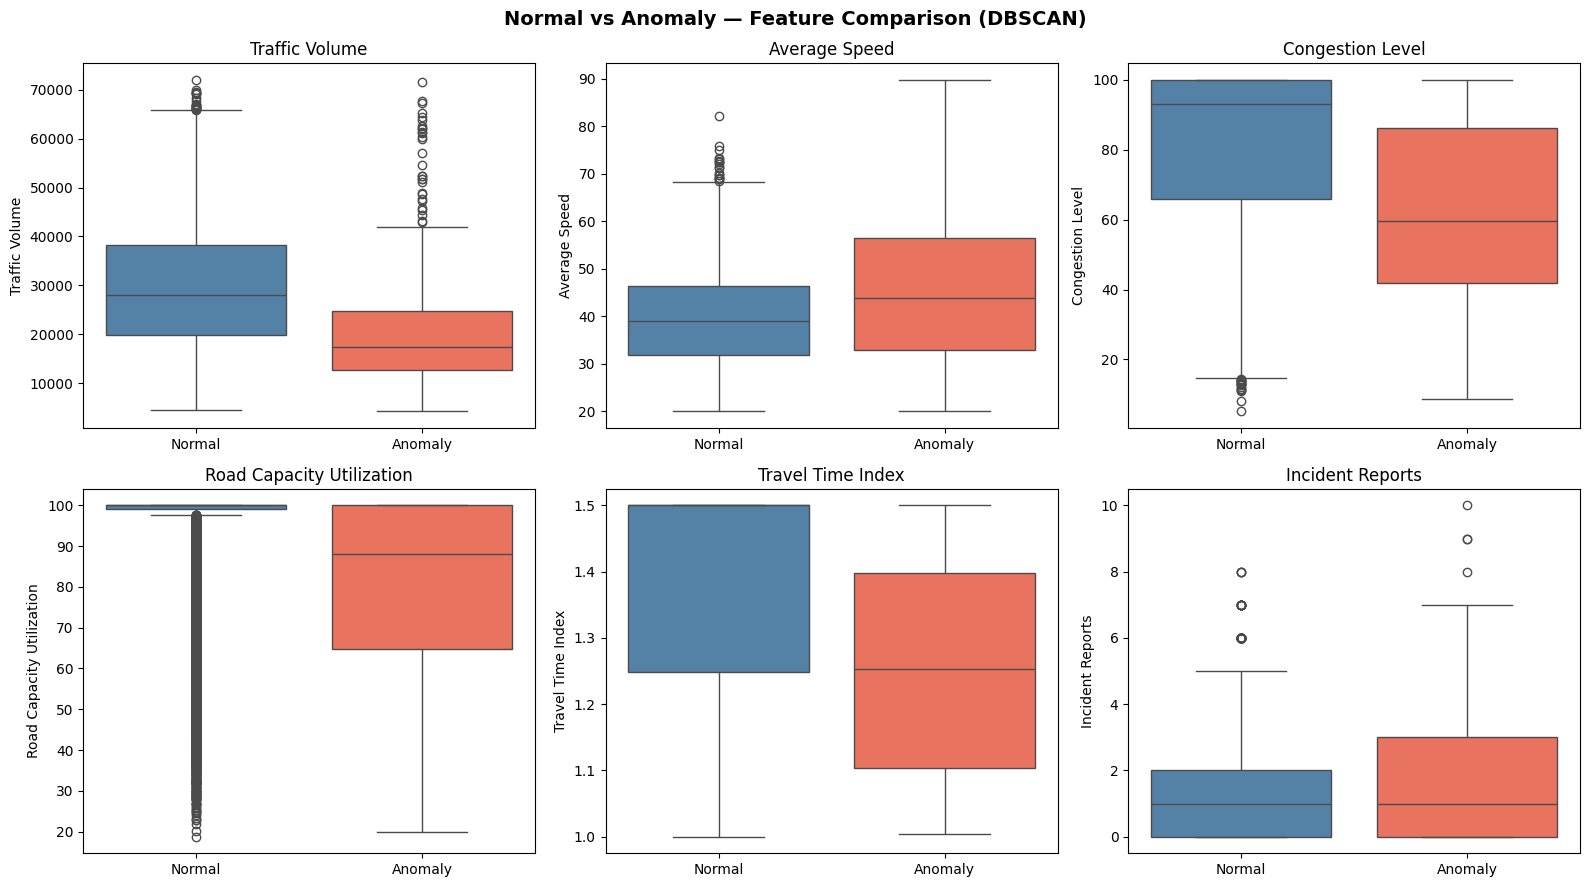

In [ ]:
df_model['Is_Anomaly'] = (df_model['DBSCAN_Label'] == -1).astype(int)

print("Anomaly vs Normal — Mean Feature Comparison:")
anomaly_profile = df_model.groupby('Is_Anomaly')[profile_cols].mean().round(2)
anomaly_profile.index = ['Normal', 'Anomaly']
print(anomaly_profile)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Normal vs Anomaly — Feature Comparison (DBSCAN)', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), profile_cols):
    sns.boxplot(data=df_model, x='Is_Anomaly', y=col, palette=['steelblue', 'tomato'], ax=ax)
    ax.set_xticklabels(['Normal', 'Anomaly'])
    ax.set_title(col)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('dbscan_anomaly_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 22 — DBSCAN: Anomalies by Area & Weather

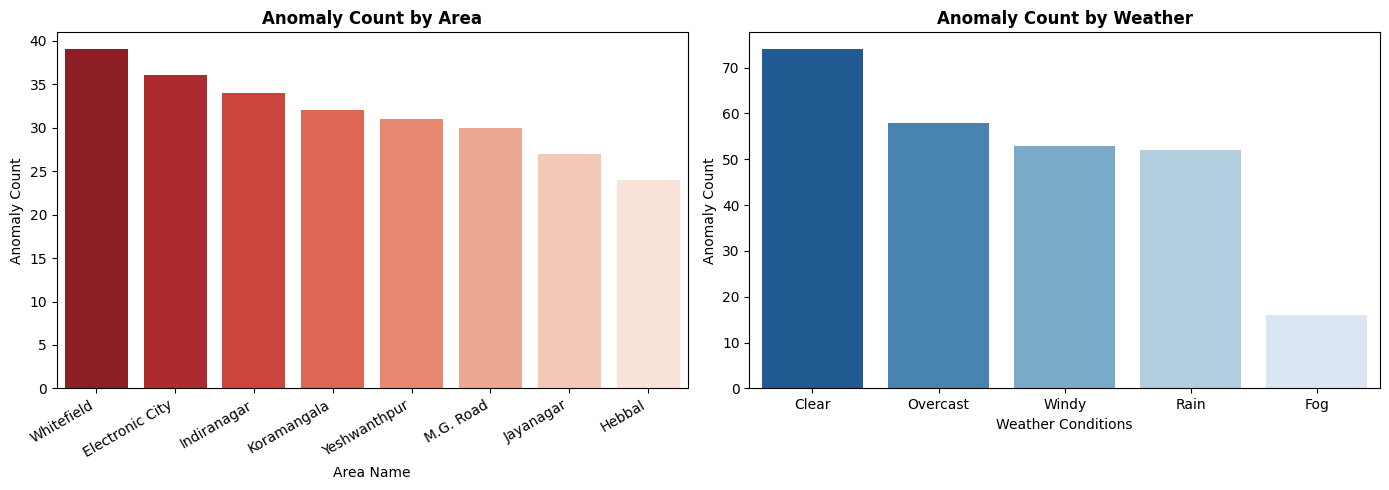

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

anomaly_area = df_model[df_model['Is_Anomaly'] == 1]['Area Name'].value_counts()
sns.barplot(x=anomaly_area.index, y=anomaly_area.values, palette='Reds_r', ax=axes[0])
axes[0].set_title('Anomaly Count by Area', fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].set_ylabel('Anomaly Count')

anomaly_weather = df_model[df_model['Is_Anomaly'] == 1]['Weather Conditions'].value_counts()
sns.barplot(x=anomaly_weather.index, y=anomaly_weather.values, palette='Blues_r', ax=axes[1])
axes[1].set_title('Anomaly Count by Weather', fontweight='bold')
axes[1].set_ylabel('Anomaly Count')

plt.tight_layout()
plt.savefig('dbscan_anomaly_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 23 — K-Means vs DBSCAN Side-by-Side

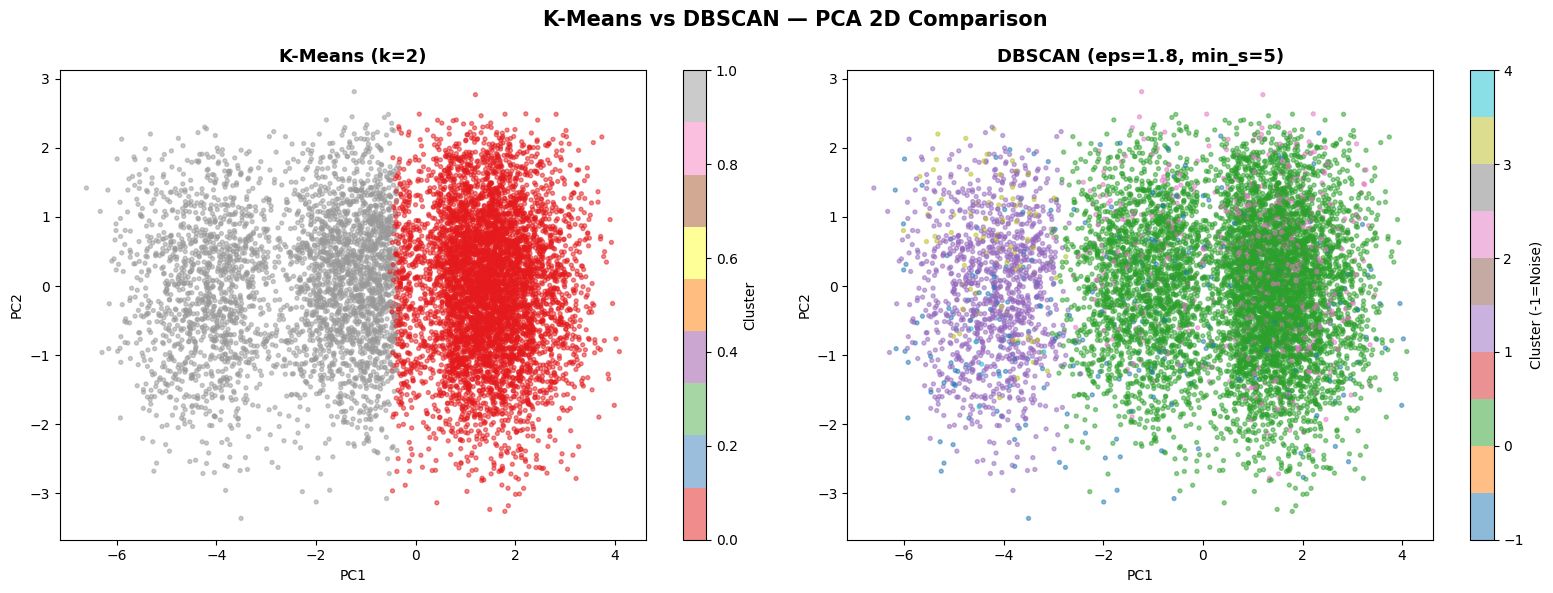

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                            c=df_model['KMeans_Cluster'], cmap='Set1', s=8, alpha=0.5)
axes[0].set_title(f'K-Means (k={OPTIMAL_K})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                            c=df_model['DBSCAN_Label'], cmap='tab10', s=8, alpha=0.5)
axes[1].set_title(f'DBSCAN (eps={BEST_EPS}, min_s={BEST_MIN_SAMPLES})', fontsize=13, fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1], label='Cluster (-1=Noise)')

plt.suptitle('K-Means vs DBSCAN — PCA 2D Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_kmeans_dbscan.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 24 — Final Metrics Summary

In [ ]:
print("=" * 55)
print("         FINAL MODEL METRICS SUMMARY")
print("=" * 55)

km_sil = silhouette_score(X_scaled, df_model['KMeans_Cluster'])
km_db  = davies_bouldin_score(X_scaled, df_model['KMeans_Cluster'])
km_ch  = calinski_harabasz_score(X_scaled, df_model['KMeans_Cluster'])

print(f"\nK-Means (k={OPTIMAL_K})")
print(f"  Silhouette Score      : {km_sil:.4f}  (↑ higher=better, max=1)")
print(f"  Davies-Bouldin Score  : {km_db:.4f}  (↓ lower=better)")
print(f"  Calinski-Harabasz     : {km_ch:.2f}  (↑ higher=better)")
print(f"  Clusters Formed       : {OPTIMAL_K}")

non_noise_mask = df_model['DBSCAN_Label'] != -1
if n_clusters_db >= 2:
    db_sil = silhouette_score(X_scaled[non_noise_mask], df_model['DBSCAN_Label'][non_noise_mask])
    db_db_score = davies_bouldin_score(X_scaled[non_noise_mask], df_model['DBSCAN_Label'][non_noise_mask])
    print(f"\nDBSCAN (eps={BEST_EPS}, min_samples={BEST_MIN_SAMPLES})")
    print(f"  Silhouette Score      : {db_sil:.4f}  (excl. noise)")
    print(f"  Davies-Bouldin Score  : {db_db_score:.4f}  (excl. noise)")
    print(f"  Clusters Found        : {n_clusters_db}")
    print(f"  Noise/Anomaly Points  : {n_noise_db} ({n_noise_db/len(db_labels)*100:.1f}%)")

print("\n" + "=" * 55)
print("K-Means  → Zone segmentation (structured clusters)")
print("DBSCAN   → Anomaly/hotspot detection (noise = alert)")
print("=" * 55)

         FINAL MODEL METRICS SUMMARY

K-Means (k=2)
  Silhouette Score      : 0.2673  (↑ higher=better, max=1)
  Davies-Bouldin Score  : 1.5232  (↓ lower=better)
  Calinski-Harabasz     : 3501.53  (↑ higher=better)
  Clusters Formed       : 2

DBSCAN (eps=1.8, min_samples=5)
  Silhouette Score      : 0.2099  (excl. noise)
  Davies-Bouldin Score  : 1.4952  (excl. noise)
  Clusters Found        : 5
  Noise/Anomaly Points  : 253 (2.8%)

K-Means  → Zone segmentation (structured clusters)
DBSCAN   → Anomaly/hotspot detection (noise = alert)


## Cell 25 — Save Final Dataset

In [ ]:
df_model.to_csv('bangalore_traffic_clustered.csv', index=False)
print("✅ Saved: bangalore_traffic_clustered.csv")
print("Columns added: KMeans_Cluster, Zone Label, DBSCAN_Label, Is_Anomaly")
df_model[['Area Name', 'Road/Intersection Name', 'KMeans_Cluster', 'Zone Label',
           'DBSCAN_Label', 'Is_Anomaly']].head(10)

✅ Saved: bangalore_traffic_clustered.csv
Columns added: KMeans_Cluster, Zone Label, DBSCAN_Label, Is_Anomaly


,Area Name,Road/Intersection Name,KMeans_Cluster,Zone Label,DBSCAN_Label,Is_Anomaly
0,Indiranagar,100 Feet Road,0,Critical Zone,0,0
1,Indiranagar,CMH Road,0,Critical Zone,0,0
2,Whitefield,Marathahalli Bridge,1,Moderate Zone,1,0
3,Koramangala,Sony World Junction,0,Critical Zone,0,0
4,Koramangala,Sarjapur Road,0,Critical Zone,0,0
5,M.G. Road,Trinity Circle,0,Critical Zone,0,0
6,M.G. Road,Anil Kumble Circle,0,Critical Zone,0,0
7,Jayanagar,Jayanagar 4th Block,0,Critical Zone,0,0
8,Jayanagar,South End Circle,0,Critical Zone,0,0
9,Hebbal,Hebbal Flyover,0,Critical Zone,0,0
